In [110]:
#import libraries
from datetime import datetime
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [111]:
#define variables
starting_balance = 100
ma = 10

In [112]:
#daily data
start = datetime(2015, 1, 1)
end = datetime(2025, 1, 1)
ticker = "AAPL"
interval = "1d"

In [113]:
#downloading price data
price = yf.download(tickers=ticker, start=start, end=end, interval=interval, multi_level_index=False)

price

C:\Users\user\AppData\Local\Temp\ipykernel_14604\3382676102.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(tickers=ticker, start=start, end=end, interval=interval, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2015-01-06,23.534943,23.794079,23.173922,23.596958,263188400
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000
...,...,...,...,...,...
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300


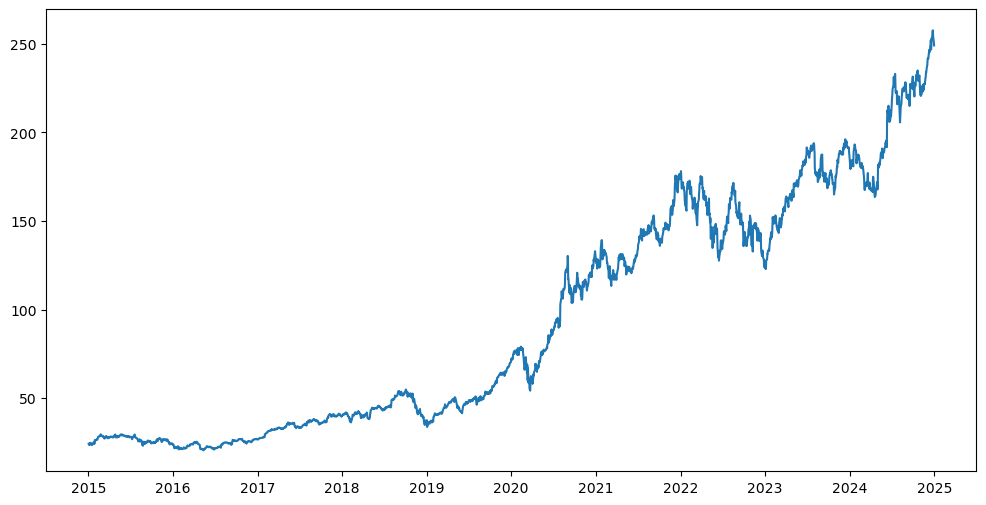

In [114]:
#plotting the price data
plt.figure(figsize=(12, 6))
plt.plot(price["Close"])

In [115]:
#Calculate daily returns
price["Return"] =  price.Close / price.Close.shift(1)
price.Return.iat[0] = 1
price["Bench_Bal"] = starting_balance * price.Return.cumprod()
price

,Close,High,Low,Open,Volume,Return,Bench_Bal
Date,,,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400,1.000000,100.000000
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000,0.971828,97.182830
2015-01-06,23.534943,23.794079,23.173922,23.596958,263188400,1.000094,97.192007
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600,1.014022,98.554836
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000,1.038422,102.341524
...,...,...,...,...,...,...,...
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700,1.011478,1060.492759
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100,1.003176,1063.860608
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300,0.986758,1049.772744


In [116]:
first_timestamp = price.index.min()
last_timestamp = price.index.max()

#calculate the number of years
years = (last_timestamp - first_timestamp).days /365.25

price["Bench_Peak"] = price.Bench_Bal.cummax()
price["Bench_DD"] = price.Bench_Bal - price.Bench_Peak

cagr_bench = (((price.Bench_Bal.iloc[-1] / price.Bench_Bal.iloc[0]) ** (1/years)) - 1) * 100
dd_bench = ((price.Bench_DD / price.Bench_Peak).min()) * 100
dd_bench

-38.515917479430314

In [117]:
#Calculate indicators
price["MA"] = price.Close.rolling(window=ma).mean()
price["long"] = price.Close > price.MA
price

,Close,High,Low,Open,Volume,Return,Bench_Bal,Bench_Peak,Bench_DD,MA,long
Date,,,,,,,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400,1.000000,100.000000,100.000000,0.000000,NaN,False
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000,0.971828,97.182830,100.000000,-2.817170,NaN,False
2015-01-06,23.534943,23.794079,23.173922,23.596958,263188400,1.000094,97.192007,100.000000,-2.807993,NaN,False
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600,1.014022,98.554836,100.000000,-1.445164,NaN,False
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000,1.038422,102.341524,102.341524,0.000000,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700,1.011478,1060.492759,1060.492759,0.000000,249.924741,True
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100,1.003176,1063.860608,1063.860608,0.000000,251.170932,True
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300,0.986758,1049.772744,1063.860608,-14.087865,251.929784,True


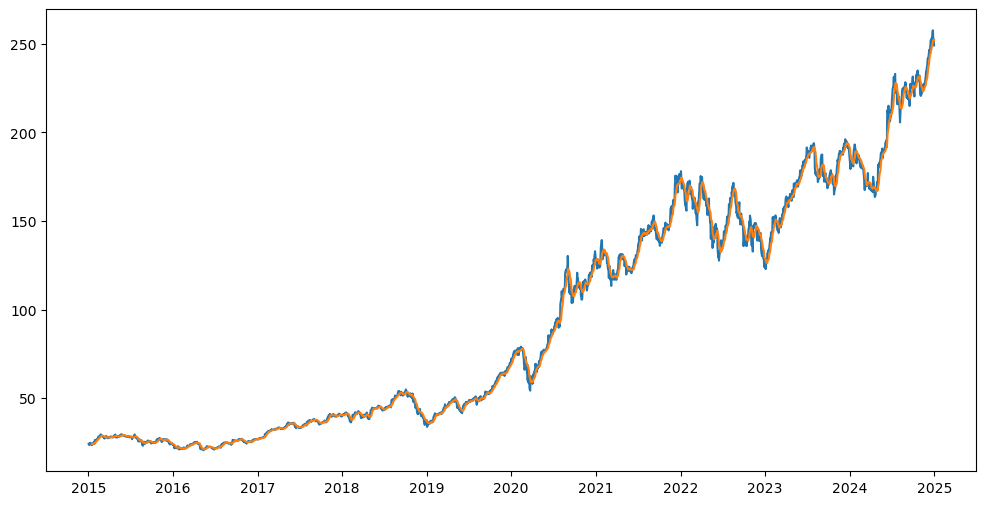

In [118]:
plt.figure(figsize=(12, 6))
plt.plot(price.Close)
plt.plot(price.MA)

In [119]:
price["Sys_Ret"] = np.where(price.long.shift(1) == True, price.Return, 1)
price["Sys_Bal"] = starting_balance * price.Sys_Ret.cumprod()
price

,Close,High,Low,Open,Volume,Return,Bench_Bal,Bench_Peak,Bench_DD,MA,long,Sys_Ret,Sys_Bal
Date,,,,,,,,,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400,1.000000,100.000000,100.000000,0.000000,NaN,False,1.000000,100.000000
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000,0.971828,97.182830,100.000000,-2.817170,NaN,False,1.000000,100.000000
2015-01-06,23.534943,23.794079,23.173922,23.596958,263188400,1.000094,97.192007,100.000000,-2.807993,NaN,False,1.000000,100.000000
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600,1.014022,98.554836,100.000000,-1.445164,NaN,False,1.000000,100.000000
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000,1.038422,102.341524,102.341524,0.000000,NaN,False,1.000000,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700,1.011478,1060.492759,1060.492759,0.000000,249.924741,True,1.011478,448.610946
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100,1.003176,1063.860608,1063.860608,0.000000,251.170932,True,1.003176,450.035617
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300,0.986758,1049.772744,1063.860608,-14.087865,251.929784,True,0.986758,444.076152


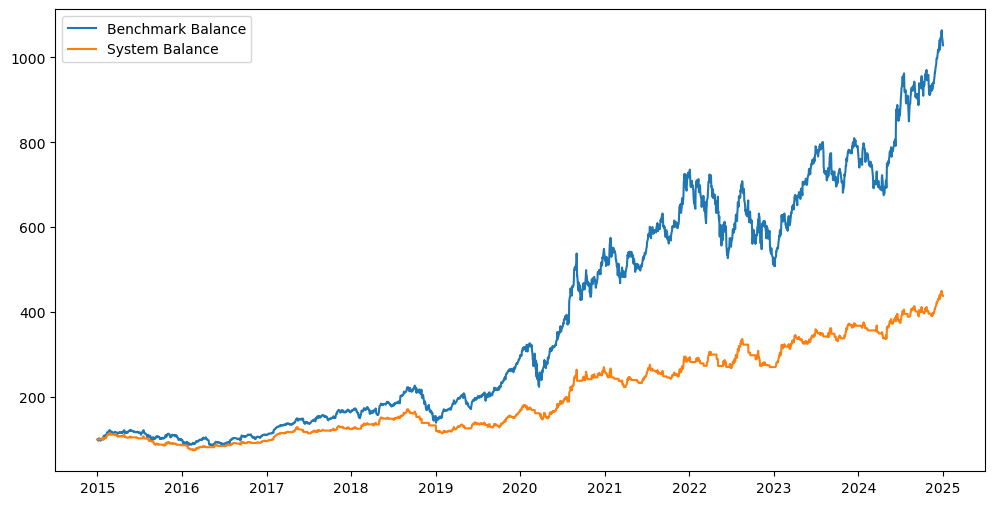

In [120]:
plt.figure(figsize=(12, 6))
plt.plot(price.Bench_Bal, label="Benchmark Balance")
plt.plot(price.Sys_Bal, label="System Balance")

plt.legend()
plt.show()